In [14]:
# Authors: Eric Larson <larson.eric.d@gmail.com>
#          Sheraz Khan <sheraz@khansheraz.com>
#          Denis Engemann <denis.engemann@gmail.com>
#
# License: BSD (3-clause)

import os.path as op

import matplotlib.pyplot as plt
import mne
import numpy as np
from mne.minimum_norm import apply_inverse_epochs, make_inverse_operator
from mne.preprocessing import compute_proj_ecg, compute_proj_eog

import mne_connectivity
from mne_connectivity import envelope_correlation

data_path = '/fast2/BIDS'
subjects_dir = op.join(data_path, "derivatives", "freesurfer","subjects")
subject = 'sub-ON56044'
trans = op.join(data_path, 'derivatives', 'ENIGMA_MEG', subject, 'ses-01', 'meg', f'{subject}_ses-01_task-rest_run-01_trans.fif')
src_fname = op.join(data_path, 'derivatives', 'ENIGMA_MEG', subject, 'ses-01', 'meg', f'{subject}_ses-01_src.fif')
bem = op.join(data_path, 'derivatives', 'ENIGMA_MEG', subject, 'ses-01', 'meg', f'{subject}_ses-01_bem.fif')
raw_fname = op.join(data_path, subject, 'ses-01', 'meg', f'{subject}_ses-01_task-rest_run-01_meg.ds')

In [15]:
raw = mne.io.read_raw_ctf(raw_fname)

ds directory : /fast2/BIDS/sub-ON56044/ses-01/meg/sub-ON56044_ses-01_task-rest_run-01_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       1.30   64.41    0.00 mm <->    1.30   64.41   -0.00 mm (orig :  -28.48   55.89 -265.64 mm) diff =    0.000 mm
      -1.30  -64.41    0.00 mm <->   -1.30  -64.41   -0.00 mm (orig :   43.60  -50.63 -257.95 mm) diff =    0.000 mm
      90.23    0.00    0.00 mm <->   90.23    0.00   -0.00 mm (orig :   76.57   53.56 -233.76 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 HPI coils added
    Measurement info composed.
Finding samples for /fast2/BIDS/sub-ON56044/ses-01/meg/sub-ON56044_ses-01_task-rest_run-01_meg.ds/sub-ON56044_ses-01_task-rest_run-01_meg.meg4: 
    System clock channel is available, checking which samples are valid.
    1 x 432000 = 432000 samples

In [3]:
raw.pick_types(meg=True, eeg=False).load_data().resample(80)
raw.apply_gradient_compensation(3)
raw.filter(0.1, None)  # this helps with symmetric orthogonalization later
cov = mne.compute_raw_covariance(raw)  # compute before band-pass of interest

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 431999  =      0.000 ...   359.999 secs...
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Filter length: 2641 samples (33.013 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.2s


Using up to 1800 segments


[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.3s


Number of samples used : 28800
[done]


In [4]:
src = mne.read_source_spaces(src_fname)
fwd = mne.make_forward_solution(raw.info, trans, src, bem, verbose=True)
lcmv = mne.beamformer.make_lcmv(raw.info, fwd, cov)

    Reading a source space...
    Computing patch statistics...
    Patch information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    [done]
    2 source spaces read
Source space          : <SourceSpaces: [<surface (lh), n_vertices=121149, n_used=4098>, <surface (rh), n_vertices=118167, n_used=4098>] MRI (surface RAS) coords, subject 'sub-ON56044', ~20.4 MB>
MRI -> head transform : /fast2/BIDS/derivatives/ENIGMA_MEG/sub-ON56044/ses-01/meg/sub-ON56044_ses-01_task-rest_run-01_trans.fif
Measurement data      : instance of Info
Conductor model   : /fast2/BIDS/derivatives/ENIGMA_MEG/sub-ON56044/ses-01/meg/sub-ON56044_ses-01_bem.fif
Accurate field computations
Do computations in head coordinates
Free source orientations

Read 2 source spaces a total of 8196 active source locations

Coordinate transformation: MRI (surface RAS) -> head
     0.996546 -0.010951 -0.082317      -0.38 mm
     0.042355  0.919668  0.390405      -5

In [5]:
stcs = mne.beamformer.apply_lcmv_raw(raw, lcmv)

combining the current components...


In [6]:
labels = mne.read_labels_from_annot(subject, "aparc.a2009s", subjects_dir=subjects_dir)
label_ts = mne.extract_label_time_course(stcs, labels, src)

Reading labels from parcellation...
   read 75 labels from /fast2/BIDS/derivatives/freesurfer/subjects/sub-ON56044/label/lh.aparc.a2009s.annot
   read 75 labels from /fast2/BIDS/derivatives/freesurfer/subjects/sub-ON56044/label/rh.aparc.a2009s.annot
Extracting time courses for 150 labels (mode: mean_flip)


In [7]:
label_ts_orth = mne_connectivity.envelope.symmetric_orth(label_ts)

In [8]:
label_ts_orth_beta = mne.filter.filter_data(label_ts_orth, 80, 14 ,30)

Setting up band-pass filter from 14 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 14.00
- Lower transition bandwidth: 3.50 Hz (-6 dB cutoff frequency: 12.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 77 samples (0.963 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.1s


In [9]:
corr_obj = envelope_correlation(  # already orthogonalized earlier
    [label_ts_orth_beta], orthogonalize=False
)

In [10]:
# average over epochs, take absolute value, and plot
corr = corr_obj.combine()
corr = corr.get_data(output="dense")[:, :, 0]
corr.flat[:: corr.shape[0] + 1] = 0  # zero out the diagonal
corr = np.abs(corr)

In [11]:
n = corr.shape[0]

# Generate indices for left and right ROIs
left_indices = list(range(0, n, 2))   # Even indices: 0, 2, 4,...
right_indices = list(range(1, n, 2))  # Odd indices: 1, 3, 5,...

# New index order: lefts first, then rights
new_order = left_indices + right_indices

# Reorder the matrix
corr_shuffle = corr[np.ix_(new_order, new_order)]

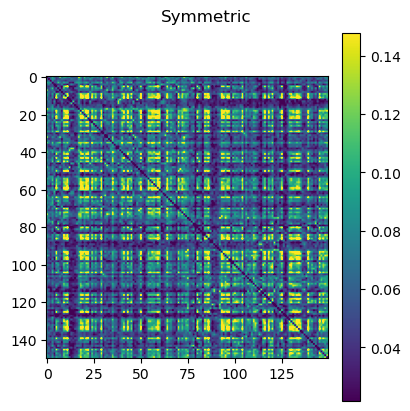

In [12]:
def plot_corr(corr, title):
    fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
    s=ax.imshow(corr, cmap="viridis", clim=np.percentile(corr, [5, 95]))
    fig.suptitle(title)
    fig.colorbar(s)

plot_corr(corr_shuffle, "Symmetric")

In [13]:
import os
output_dir = '/fast2/BIDS/derivatives/envcorr_outputs/'
os.makedirs(output_dir, exist_ok=True)
np.save(f'{output_dir}/{subject}_envcorr_sym.npy', corr_shuffle)